In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.gridspec import GridSpec
import matplotlib.image as image
from scipy import stats

In [8]:
sys.path.insert(1, './utils/')

In [3]:
# from load_data import *
# from plot_functions import *
from utils_functions import *

def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj][0]


In [4]:
#load data
#filename = "./data/data_shift_cells_ON.pkl"
filename = f"../data_experiments/data_shift_cells_ON.pkl"

with open(filename, "rb") as handle:  
    cells_dict = pickle.load(handle)   
# with open("{}_for_sta.pkl".format(filename[:-4]), "rb") as handle:  
#     cells_dict_for_sta = pickle.load(handle)  
    
        
all_frequencies = ['6_Hz','8_Hz','10_Hz','12_Hz','16_Hz']
all_periods = np.array([170,120,100,80,60])
use_for_example = [0,2,4]
sub_frequencies = ['6_Hz','12_Hz','16_Hz']

    
#get traces for panel A

cell = 'cell_4' # choose example cell
    
times = [cells_dict[cell]['response_data']['osr_times'][i]
         -cells_dict[cell]['response_data']['lastflashends'][i] for i in use_for_example]


flashstarts = [cells_dict[cell]['response_data']['flashstarts'][i]
               -cells_dict[cell]['response_data']['lastflashends'][i] for i in use_for_example]
flashends = [cells_dict[cell]['response_data']['flashends'][i]
               -cells_dict[cell]['response_data']['lastflashends'][i] for i in use_for_example]


responses_control = [cells_dict[cell]['response_data']['responses_control'][i] for i in use_for_example]
responses_strychnine = [cells_dict[cell]['response_data']['responses_strychnine'][i] for i in use_for_example]


#get delays for panel B 
delays_control = np.array(cells_dict[cell]['slope_data']['peaks_control'])
delays_strychnine = np.array(cells_dict[cell]['slope_data']['peaks_strych'])

amps_control = np.array(cells_dict[cell]['slope_data']['amps_control'])
amps_strychnine = np.array(cells_dict[cell]['slope_data']['amps_strych'])


slope_control = cells_dict[cell]['slope_data']['slope_control']
slope_strych = cells_dict[cell]['slope_data']['slope_strych']

offset_control = cells_dict[cell]['slope_data']['offset_control']*1000
offset_strych = cells_dict[cell]['slope_data']['offset_strych']*1000


#get mean delays for panel C
delays_control_mean = cells_dict['mean']['mean_peaks_control_rel']
delays_control_mean_OS = cells_dict['mean']['mean_peaks_control_OS_rel']
delays_strychnine_mean = cells_dict['mean']['mean_peaks_strych_rel']
delays_strychnine_mean_OS = cells_dict['mean']['mean_peaks_strych_OS_rel']

delays_control_std = cells_dict['std']['std_peaks_control_rel']
delays_control_std_OS = cells_dict['std']['std_peaks_control_OS_rel']
delays_strychnine_std = cells_dict['std']['std_peaks_strych_rel']
delays_strychnine_std_OS = cells_dict['std']['std_peaks_strych_OS_rel']


#get slope and p-value for panel D
all_slopes_control = cells_dict['mean']['all_slopes_control']
all_slopes_strychnine = cells_dict['mean']['all_slopes_strychnine']

mean_amps_control = cells_dict['mean']['mean_amps_control']
mean_amps_strychnine = cells_dict['mean']['mean_amps_strychnine']
std_amps_control = cells_dict['std']['std_amps_control']
std_amps_strychnine = cells_dict['std']['std_amps_strychnine']


all_amps_control = cells_dict['mean']['all_amps_control'] 
all_amps_strychnine = cells_dict['mean']['all_amps_strychnine'] 



omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]


frequencies = all_frequencies

In [5]:
# load simulation
filename_sim_starts = '../data_experiments/peakstarts_simulation'

with open(filename_sim_starts, "rb") as handle:   #Pickling
    peakstarts_simulation = pickle.load( handle)

# significance amplitudes control vs strychnine

In [9]:

#significance_amps = []
pvalues = []
for i in range(len(frequencies)):

    stat, p = stats.ttest_rel(np.asarray(all_amps_control)[:,i],
                              np.asarray(all_amps_strychnine)[:,i] ,
                              nan_policy='omit')        
    pvalues.append(p)
    #significance_amps.append(evaluate_significance(p))
    #significance_amps.append(evaluate_significance_bonferroni(p,5))

    
#significance_amps = np.flip(significance_amps)

In [10]:
significance_amps = evaluate_significance_bonferroni_holm(pvalues,frequencies)

ns, p = 2.60e-01
ns, p = 2.97e-01
ns, p = 7.51e-01
ns, p = 8.01e-01
ns, p = 9.75e-01


# significance spike onset control vs. delay

In [11]:
cells_dict['mean'].keys()

dict_keys(['mean_peaks_control_rel', 'mean_peaks_control_OS_rel', 'mean_peaks_strych_rel', 'mean_peaks_strych_OS_rel', 'mean_peaks_control_abs', 'mean_peaks_control_OS_abs', 'mean_peaks_strych_abs', 'mean_peaks_strych_OS_abs', 'all_slopes_control', 'all_slopes_strychnine', 'all_amps_control', 'all_amps_strychnine', 'mean_amps_control', 'mean_amps_strychnine', 'mean_starts_control_rel', 'mean_starts_control_abs', 'all_starts_control_rel', 'all_starts_control_abs', 'mean_starts_strychnine_rel', 'mean_starts_strychnine_abs', 'all_starts_strychnine_rel', 'all_starts_strychnine_abs', 'all_slopes_start_control', 'all_slopes_start_strychnine', 'all_offsets_start_control', 'all_offsets_start_strychnine', 'slope_start_control', 'slope_start_strychnine', 'offset_start_control', 'offset_start_strychnine'])

In [12]:

#significance_amps = []
pvalues = []
for i in range(len(frequencies)):
    stat, p = stats.ttest_rel(np.asarray(cells_dict['mean']['all_starts_control_rel'])[:,i],
                              np.asarray(cells_dict['mean']['all_starts_strychnine_rel'])[:,i],
                              nan_policy='omit')        
    pvalues.append(p)
    #significance_amps.append(evaluate_significance(p))
    #significance_amps.append(evaluate_significance_bonferroni(p,5))

    
#significance_amps = np.flip(significance_amps)

In [13]:
evaluate_significance_bonferroni_holm(pvalues,frequencies)

*, p = 7.14e-03
*, p = 9.08e-03
ns, p = 2.93e-02
ns, p = 3.96e-02
ns, p = nan


/Users/simone/Documents/Repositories/osr_model/Figure_codes/utils/utils_functions.py:188: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues_df['significance'].iloc[i] = "*"
/Users/simone/Documents/Repositories/osr_model/Figure_codes/util

[[0.007144311295048833, '*'],
 [0.03956256730343673, 'ns'],
 [nan, 'ns'],
 [0.029317456802675064, 'ns'],
 [0.009083139120310363, '*']]

# significance slope in onset control and strychnine

In [14]:
#stat, p = stats.ttest_rel(all_slopes_control, all_slopes_strychnine)
stat, p = stats.ttest_ind(cells_dict['mean']['all_slopes_start_control'], cells_dict['mean']['all_slopes_start_strychnine'], equal_var=False)
if p < 0.05:
    print(f"significant difference, p = {p:.2e}")
if p > 0.05 : 
    print(f"NOT significant, p = {p:.2e}")


NOT significant, p = 5.66e-02


# compare mean slope in experiments and simulation for spiking onset

In [15]:
# calculate mean and sem for slope in spinkin onset

mean_slope_start_control = cells_dict['mean']['slope_start_control']
mean_slope_start_strychnine = cells_dict['mean']['slope_start_strychnine']

std_slope_start_control = cells_dict['std']['slope_start_control']
std_slope_start_strychnine = cells_dict['std']['slope_start_strychnine']


print(f'mean slope control: {mean_slope_start_control}')
print(f's. e. m. : {std_slope_start_control}')
print(f'mean slope strychnine: {mean_slope_start_strychnine }')
print(f's. e. m. : {std_slope_start_strychnine}')

sc = peakstarts_simulation['slope_control']
ss = peakstarts_simulation['slope_strychine']
print(f'simulation control: {sc}')
print(f'simulation strychnine: {ss}')


mean slope control: 0.4352992443122314
s. e. m. : 0.12011676307554277
mean slope strychnine: 0.019157134877569204
s. e. m. : 0.15652313395454318
simulation control: 1.1392235705236946
simulation strychnine: 0.37700108350139866


In [19]:
# load simulation

fn = 12

simulation_fixed = load_dict(f'../output/params_final_nonlin_strych/simulation_osr_{fn}.pickle')
simulation_dynamic = load_dict(f'../output/params_final_nonlin/simulation_osr_{fn}.pickle')




keys = simulation_dynamic['simulations'].keys()

frequencies = simulation_dynamic['osrparams']['frequencies']
periods = np.round(1/frequencies,2)*1000

times = [simulation_dynamic['simulations'][key]['time']-simulation_dynamic['simulations'][key]['lastflash_tp']
         for key in keys]
#time2 = simulation2['simulations'][key]['time']

flashes =[np.where(np.diff(simulation_dynamic['simulations'][key]['stimulus']) != 0)[0].tolist() for key in keys]

lastflashends = [simulation_dynamic['simulations'][key]['lastflash_tp'] for key in keys]
#lastflashend2 = simulation2['simulations'][key]['lastflash_tp']


# simulation dynamic
responses_dynamic = [simulation_dynamic['simulations'][key]['RG'] for key in keys]
delays_dynamic = [simulation_dynamic['simulations'][key]['delay'] for key in keys]
peak_amps_dynamic = [simulation_dynamic['simulations'][key]['peak_amplitude'] for key in keys]



delays_all_dynamic = simulation_dynamic['delays']*1000
slope_dynamic = simulation_dynamic['slope']
offset_dynamic =  simulation_dynamic['offset']*1000 

delays_all_dynamic_relative = delays_all_dynamic - delays_all_dynamic[-1]
offset_dynamic_relative =  simulation_dynamic['offset']*1000 - delays_all_dynamic[-1]


# simulation fixed
responses_fixed = [simulation_fixed['simulations'][key]['RG'] for key in keys]
delays_fixed = [simulation_fixed['simulations'][key]['delay'] for key in keys]
peak_amps_fixed = [simulation_fixed['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_fixed = simulation_fixed['delays']*1000
slope_fixed = simulation_fixed['slope']
offset_fixed =  simulation_fixed['offset']*1000

delays_all_fixed_relative = delays_all_fixed - delays_all_dynamic[-1]
offset_fixed_relative =  simulation_fixed['offset']*1000 - delays_all_dynamic[-1]


In [20]:
ms = 20
fontsize_ticks = 15
fontsize_labels = 25

lw = 4

In [21]:
periods,peak_amps_dynamic

(array([170., 120., 100.,  80.,  60.]),
 [6.230352475241812,
  12.672644117778683,
  19.755659394525548,
  25.733778135399664,
  40.856057381689446])

# individual cells spiking onset

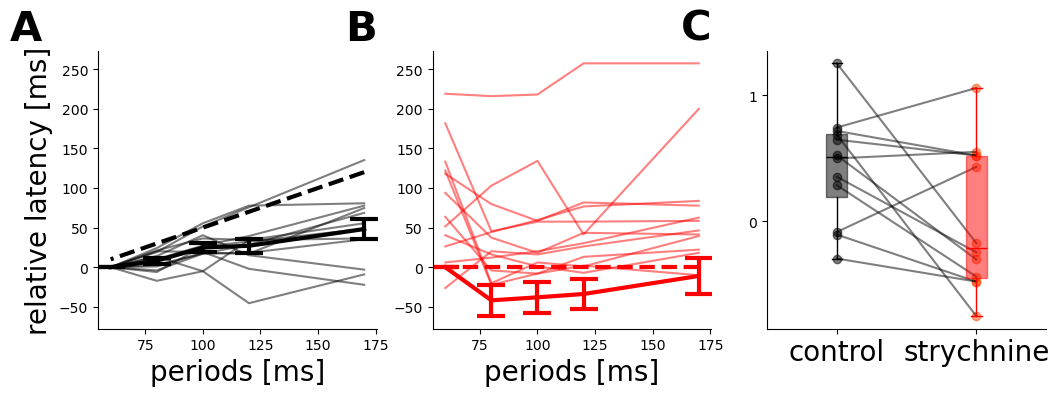

In [33]:

fontsize_panellabel = 30
fontsize_ticks = 25
fontsize_legend = 20
lw = 3
ms = 20
panellabel_position = [-0.2, 1.15]




fig = plt.figure(figsize = (12,4))
gs = fig.add_gridspec(1,3)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharey = ax0)
C2 = fig.add_subplot(gs[2])

fig.subplots_adjust(top=0.88,
bottom=0.185,
left=0.11,
right=0.9,
hspace=0.2,
wspace=0.2)

# plot all slopes peak vs start relative latency
for cell in list(cells_dict.keys())[:-2]: 
    ax0.plot(periods,np.asarray(cells_dict[cell]['response_data']['peakstarts_control']-cells_dict[cell]['response_data']['peakstarts_control'][-1])*1000, color = 'k', alpha = 0.5)
    ax1.plot(periods,np.asarray(cells_dict[cell]['response_data']['peakstarts_strychnine']-cells_dict[cell]['response_data']['peakstarts_control'][-1])*1000, color = 'r', alpha = 0.5)

ax0.plot(periods,slope_fun(periods,1,-50), color = 'k', linestyle = '--', linewidth = lw)
ax1.plot(periods,slope_fun(periods,0,0), color = 'r', linestyle = '--', linewidth = lw)


ax1.errorbar(periods,cells_dict['mean']['mean_starts_strychnine_rel'],
           linewidth = lw, label = '12 exp',yerr = cells_dict['std']['std_starts_strychnine_rel'],
            capsize = 10, capthick = lw, color = 'r')
ax0.errorbar(periods,cells_dict['mean']['mean_starts_control_rel'],
           linewidth = lw, label = '5 exp',yerr = cells_dict['std']['std_starts_control_rel'],
            capsize = 10, capthick = lw, color = 'k')


# add panel labels
ax0.text(*panellabel_position, 'A', transform=ax0.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

# add panel labels
ax1.text(*panellabel_position, 'B', transform=ax1.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

ax0.spines['right'].set_visible(False)
ax0.spines['top'].set_visible(False)

ax0.set_xlabel('periods [ms]', fontsize = fontsize_legend)
ax1.set_xlabel('periods [ms]', fontsize = fontsize_legend)
ax0.set_ylabel('relative latency [ms]', fontsize = fontsize_legend)

ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# boxplot 
C2.scatter(np.ones(len(cells_dict['mean']['all_slopes_start_control'])),cells_dict['mean']['all_slopes_start_control'], color = 'k', alpha = 0.5)
C2.scatter(np.ones(len(cells_dict['mean']['all_slopes_start_control']))*2,cells_dict['mean']['all_slopes_start_strychnine'], color = 'orangered', alpha = 0.5)

for i,di in enumerate(cells_dict['mean']['all_slopes_start_control']):
    C2.plot([1,2], [di,cells_dict['mean']['all_slopes_start_strychnine'][i]], color = 'k', alpha = 0.5)

# add panel labels
C2.text(*panellabel_position, 'C', transform=C2.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


C2.boxplot(cells_dict['mean']['all_slopes_start_strychnine'],
                    patch_artist=True,
                    positions = [2],
                    boxprops=dict(facecolor='red', color='red', alpha = 0.5),
                    capprops=dict(color='red'),
                    whiskerprops=dict(color='red'),
                    flierprops=dict(color='red', markeredgecolor='red'),
                    medianprops=dict(color='red'),
                    )

C2.boxplot(cells_dict['mean']['all_slopes_start_control'],
                    patch_artist=True,
                    positions = [1],
                    boxprops=dict(facecolor='k', color='k', alpha = 0.5),
                    capprops=dict(color='k'),
                    whiskerprops=dict(color='k'),
                    flierprops=dict(color='k', markeredgecolor='k'),
                    medianprops=dict(color='k'),
                    )


C2.set_xticklabels(["strychnine",'control'], fontsize = fontsize_legend)
C2.spines['right'].set_visible(False)
C2.spines['top'].set_visible(False)
C2.locator_params(axis = 'y', nbins=3)